# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectif** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 5** 

### **Optimisez et interprétez les modèles**

Cette étape consiste à optimiser le meilleur modèle identifié à l'étape précédente (Compairason Supervisé) puis à interpréter les variables ayant le plus d'influence sur les prédictions.

#### **Importation des bibliothèques**

In [18]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Importation des modules**

In [19]:
# Sélection
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.inspection import permutation_importance

# Prétraitement
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modèle
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [20]:
# Chargement des ensembles créés à l'étape 4

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (1233, 33)
Test  : (309, 33)


In [21]:
print(type(X_train))
print(X_train.shape)

<class 'pandas.DataFrame'>
(1233, 33)


### **Sélection du meilleur modèle**

### **Préprocessing**

> - Les variables numériques sont imputées à l'aide de la médiane puis standardisées avec **StandardScaler**.
> - Les variables catégorielles sont imputées avec la modalité la plus fréquente, puis transformées à l'aide d'un **OneHotEncoder**.
> - Ce prétraitement est intégré au pipeline afin de garantir que les mêmes transformations soient systématiquement appliquées aux jeux d'entraînement et de test.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identification des variables numériques et catégorielles
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Variables numériques : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")

# Préprocessement
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

print("Préprocesseur créé avec succès.")
preprocessor

Variables numériques : 20
Variables catégorielles : 12
Préprocesseur créé avec succès.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### **Création du pipeline**

> - Le Random Forest, sélectionné à l'étape précédente, est intégré dans un Pipeline avec le préprocesseur.
> - Cette approche garantit que toutes les transformations (imputation, standardisation et encodage) sont appliquées de manière identique lors de chaque validation croisée.
> - Le pipeline sera utilisé comme base pour la recherche des meilleurs hyperparamètres avec GridSearchCV.

In [23]:
# Pipeline du modèle Random Forest

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Pipeline Random Forest créé avec succès.")

rf_pipeline

Pipeline Random Forest créé avec succès.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### **Optimisation avec GridSearchCV**

##### **Petite grille de test**

> - Avant d'exécuter la recherche complète, une petite grille de test a été utilisée afin de vérifier le bon fonctionnement du pipeline et de GridSearchCV. Une fois cette validation effectuée, la grille complète d'hyperparamètres a été lancée.

In [24]:
# Petite grille de test

test_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2],
    "model__min_samples_leaf": [1, 2]
}

test_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=test_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

print("Lancement de la petite grille de test...")

test_grid_search.fit(X_train, y_train)

print("Test terminé avec succès.")
print(f"Meilleur score : {test_grid_search.best_score_:.3f}")
print(test_grid_search.best_params_)

Lancement de la petite grille de test...


c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Test terminé avec succès.
Meilleur score : 0.625
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


##### **Définition de la grille d'hyperparamètres**

> - Une grille d'hyperparamètres est définie afin de tester plusieurs configurations du modèle Random Forest.

In [25]:
# Grille d'hyperparamètres

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

print("Grille d'hyperparamètres créée.")
param_grid

Grille d'hyperparamètres créée.


{'model__n_estimators': [100, 200, 300],
 'model__max_depth': [None, 10, 20, 30],
 'model__min_samples_split': [2, 5, 10],
 'model__min_samples_leaf': [1, 2, 4]}

> - La grille d'hyperparamètres explore plusieurs combinaisons des principaux paramètres du Random Forest.
> - GridSearchCV évaluera automatiquement chaque combinaison à l'aide d'une validation croisée afin d'identifier le modèle offrant les meilleures performances.
> - Cette approche permet de sélectionner les hyperparamètres les plus adaptés tout en limitant le risque de surapprentissage.

##### **Configuration du GridSearchCV**

> - Le modèle est optimisé à l'aide de **GridSearchCV**, qui évalue chaque combinaison d'hyperparamètres grâce à une validation croisée à cinq plis (*5-fold cross-validation*).
> - Le critère de sélection retenu est le coefficient de détermination (**R²**), afin d'identifier la configuration offrant les meilleures performances.

In [26]:
# Configuration du GridSearchCV

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

print("GridSearchCV configuré avec succès.")

grid_search

GridSearchCV configuré avec succès.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support

##### **Entraînement du modèle**

In [27]:
# Entraînement du modèle avec recherche d'hyperparamètres
grid_search.fit(X_train, y_train)

c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support

##### **Résultats de l'optimisation**

> - Les meilleurs hyperparamètres sont affichés après la validation croisée.
> - Le meilleur score correspond à la moyenne des performances obtenues sur les cinq plis de validation.
> - Le meilleur estimateur sera ensuite évalué sur le jeu de test, resté totalement indépendant.

In [28]:
print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)

print()

print(f"Meilleur score CV (R²) : {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

print()

print("Best estimator :")
print(best_model)

Meilleurs hyperparamètres :
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Meilleur score CV (R²) : 0.625

Best estimator :
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['osebuildingid', 'datayear',
                                                   'zipcode',
                                                   'councildistrictcode',
                                                   'latitude', 'longitude',
                                                   'numberofbuildings',
         

### **Évaluation du modèle optimisé**

>  - Le meilleur modèle obtenu par GridSearchCV est évalué sur le jeu de test.
>  - Ce jeu de données est resté totalement indépendant pendant toute la phase d'optimisation.
>  - Les performances obtenues représentent donc une estimation réaliste de la capacité de généralisation du modèle.

In [29]:
# Meilleur modèle

best_model = grid_search.best_estimator_

# Prédictions
y_pred = best_model.predict(X_test)

# Métriques
rf_opt_r2 = r2_score(y_test, y_pred)
rf_opt_mae = mean_absolute_error(y_test, y_pred)
rf_opt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {rf_opt_r2:.3f}")
print(f"MAE  : {rf_opt_mae:,.0f}".replace(",", " "))
print(f"RMSE : {rf_opt_rmse:,.0f}".replace(",", " "))

c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


R²   : 0.796
MAE  : 2 940 944
RMSE : 6 093 572


> - Le modèle optimisé obtient un coefficient de détermination (**R² = 0.796**) sur le jeu de test, ce qui confirme sa bonne capacité à expliquer la variabilité de la consommation énergétique.
> - Les erreurs (**MAE = 2 940 944** et **RMSE = 6 093 572**) restent relativement faibles au regard de l'échelle de la variable cible. Le **RMSE**, plus sensible aux erreurs importantes, étant supérieur au **MAE**, cela indique que quelques bâtiments présentent encore des écarts de prédiction plus élevés.
> - Les performances obtenues sur le jeu de test sont très proches de celles du modèle avant optimisation, ce qui montre que la recherche d'hyperparamètres n'a pas apporté d'amélioration significative, mais confirme la robustesse du modèle sélectionné.

#### **Importance des variables**

> - La **Permutation Importance** permet d'évaluer l'influence de chaque variable sur les performances du modèle.
> - Le principe consiste à mélanger aléatoirement les valeurs d'une variable puis à mesurer la diminution des performances du modèle.
> - Plus la baisse de performance est importante, plus la variable est considérée comme influente.

In [30]:
# Calcul de la permutation importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

print("Permutation Importance calculée avec succès.")

c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWar

Permutation Importance calculée avec succès.


c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['comments']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


#####  **Calcul de la permutation importance**

>  - Les variables sont classées selon leur importance moyenne calculée par la méthode de **Permutation Importance**.
>  - Les variables présentant les valeurs les plus élevées sont celles qui contribuent le plus aux performances du modèle.

In [31]:
# Création du tableau des importances

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = (
    importance_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(10)

,Variable,Importance
0,propertygfatotal,0.778115
1,largestpropertyusetypegfa,0.277601
2,propertygfabuilding(s),0.103226
3,largestpropertyusetype,0.073316
4,numberofbuildings,0.057200
5,primarypropertytype,0.043452
6,longitude,0.009546
7,secondlargestpropertyusetypegfa,0.007462
8,NumberPropertyUses,0.004434
9,neighborhood,0.002545


>  - La variable **LargestPropertyUseTypeGFA** apparaît comme la plus influente dans les prédictions du modèle.
>  - Les variables liées au type d'utilisation principal du bâtiment (**ListOfAllPropertyUseTypes** et **PrimaryPropertyType**) présentent également une forte importance.
>  - Ces résultats montrent que la surface occupée et la fonction principale du bâtiment jouent un rôle majeur dans l'estimation de la consommation énergétique.

##### **Visualisation des variables importantes**

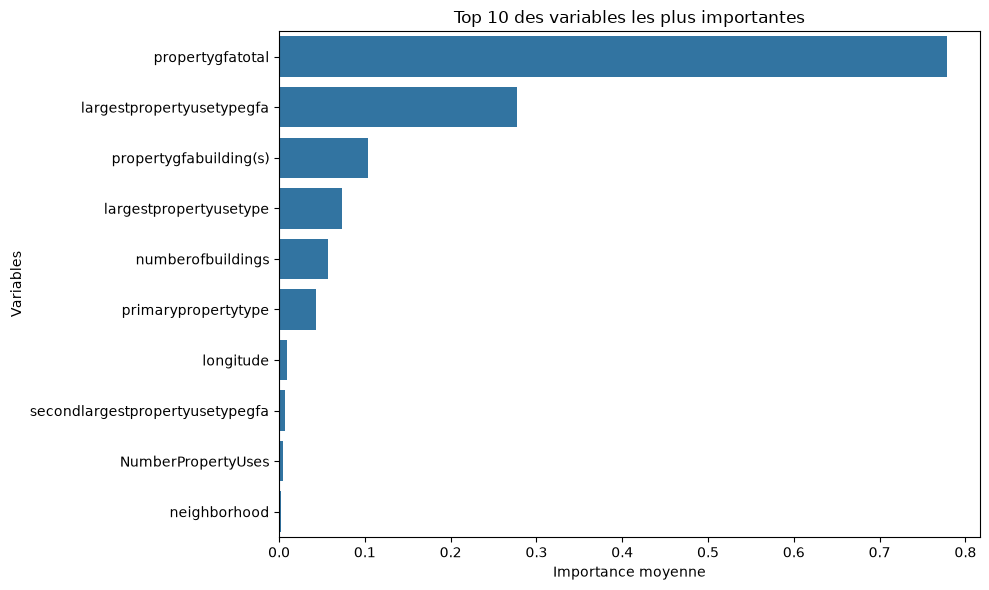

In [32]:
# Visualisation des 15 variables les plus importantes

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Variable"
)

plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance moyenne")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

>  - La **Permutation Importance** montre que **LargestPropertyUseTypeGFA** est la variable qui contribue le plus aux performances du modèle.
> - Les variables liées à la surface du bâtiment et à son usage (**LargestPropertyUseType**, **PrimaryPropertyType** et **PropertyGFAParking**) figurent également parmi les plus influentes, ce qui est cohérent avec les analyses exploratoires réalisées précédemment.
> - Cette analyse confirme que la consommation énergétique dépend principalement des caractéristiques physiques et de l'utilisation des bâtiments, tout en améliorant l'interprétabilité du modèle.


### **Conclusion**

>  - Le modèle optimisé à l'aide de **GridSearchCV** obtient un coefficient de détermination (R²) satisfaisant sur le jeu de test.
>  - La méthode de **Permutation Importance** montre que la surface du bâtiment (*LargestPropertyUseTypeGFA*) ainsi que le type d'utilisation (*ListOfAllPropertyUseTypes* et *PrimaryPropertyType*) sont les variables les plus influentes.
>  - Ces résultats indiquent que les caractéristiques physiques et fonctionnelles des bâtiments jouent un rôle majeur dans la prédiction de la consommation énergétique.
>  - Le pipeline mis en place garantit un prétraitement cohérent et une validation robuste du modèle.

### **Sauvegarde du modèle**

In [33]:
# Sauvegarde du meilleur modèle

import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Modèle sauvegardé.")

Modèle sauvegardé.
